In [1]:
import os

BASE = r"D:\Drug_Toxicity_AI"

folders = [
    "data/raw",
    "data/processed",
    "data/features",
    "models",
    "outputs/predictions",
    "outputs/metrics",
    "outputs/plots",
    "outputs/explanations",
    "notebooks",
    "logs"
]

for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("Project structure created ✅")

Project structure created ✅


In [2]:
import pandas as pd
import os

BASE = r"D:\Drug_Toxicity_AI"
raw_path = os.path.join(BASE, "data", "raw", "tox21.csv")

# Load raw dataset
data = pd.read_csv(raw_path)

print("Raw data loaded from structured folder ✅")
print("Shape:", data.shape)

# Save a backup copy (optional but good practice)
backup_path = os.path.join(BASE, "data", "raw", "tox21_backup.csv")
data.to_csv(backup_path, index=False)

print("Backup saved ✅")

Raw data loaded from structured folder ✅
Shape: (7831, 14)
Backup saved ✅


In [3]:
# Toxicity columns
tox_cols = [
    'NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase',
    'NR-ER','NR-ER-LBD','NR-PPAR-gamma',
    'SR-ARE','SR-ATAD5','SR-HSE','SR-MMP','SR-p53'
]

# Select relevant columns
df = data[["smiles"] + tox_cols].copy()

# Handle missing values
df.loc[:, tox_cols] = df[tox_cols].fillna(0)

# Save processed dataset
processed_path = os.path.join(BASE, "data", "processed", "step1_cleaned.csv")
df.to_csv(processed_path, index=False)

print("Step 2 DONE ✅")
print("Shape:", df.shape)

Step 2 DONE ✅
Shape: (7831, 13)


In [4]:
from rdkit import Chem
import os

# Convert SMILES → molecule
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

# Remove invalid molecules
df_valid = df[df["mol"].notnull()].reset_index(drop=True)

# Save WITHOUT mol column (cannot store object)
valid_path = os.path.join(BASE, "data", "processed", "step2_valid.csv")
df_valid.drop(columns=["mol"]).to_csv(valid_path, index=False)

print("Step 3 DONE ✅")
print("Valid molecules:", df_valid.shape)

[16:21:12] WARNING: not removing hydrogen atom without neighbors
[16:21:12] Explicit valence for atom # 8 Al, 6, is greater than permitted
[16:21:12] Explicit valence for atom # 3 Al, 6, is greater than permitted
[16:21:12] Explicit valence for atom # 4 Al, 6, is greater than permitted
[16:21:12] Explicit valence for atom # 4 Al, 6, is greater than permitted


Step 3 DONE ✅
Valid molecules: (7823, 14)


[16:21:13] Explicit valence for atom # 9 Al, 6, is greater than permitted
[16:21:13] Explicit valence for atom # 5 Al, 6, is greater than permitted
[16:21:13] Explicit valence for atom # 16 Al, 6, is greater than permitted
[16:21:13] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [5]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import os

# Reload clean dataset (important for reproducibility)
df = pd.read_csv(os.path.join(BASE, "data", "processed", "step2_valid.csv"))

# Recreate molecules
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

# Fingerprint function
def mol_to_fp(mol):
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 512))

# Apply
df["fp"] = df["mol"].apply(mol_to_fp)

# Create X and y
X = np.array(df["fp"].tolist())
y = df[tox_cols].values

# Save features
np.save(os.path.join(BASE, "data", "features", "X.npy"), X)
np.save(os.path.join(BASE, "data", "features", "y.npy"), y)

print("Step 4 DONE ✅")
print("X shape:", X.shape)
print("y shape:", y.shape)

[16:21:13] WARNING: not removing hydrogen atom without neighbors
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganGenerator
[16:21:14] DEPRECATION WARNING: please use MorganG

Step 4 DONE ✅
X shape: (7823, 512)
y shape: (7823, 12)


[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerator
[16:21:15] DEPRECATION WARNING: please use MorganGenerat

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np
import os

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# Save splits
np.save(os.path.join(BASE, "data", "features", "X_train.npy"), X_train)
np.save(os.path.join(BASE, "data", "features", "X_test.npy"), X_test)
np.save(os.path.join(BASE, "data", "features", "y_train.npy"), y_train)
np.save(os.path.join(BASE, "data", "features", "y_test.npy"), y_test)

print("Step 5 DONE ✅")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Step 5 DONE ✅
Train: (6258, 512)
Test: (1565, 512)


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import os

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

# Dataset + DataLoader (mini-batch)
dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# Model
class MultiLabelNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 12)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiLabelNet().to(device)

# Class imbalance handling
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts

pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5), dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
EPOCHS = 20
losses = []

for epoch in range(EPOCHS):
    total_loss = 0
    
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Save model
torch.save(model.state_dict(), os.path.join(BASE, "models", "multilabel_model.pth"))

# Save loss log
np.save(os.path.join(BASE, "logs", "training_loss.npy"), np.array(losses))

print("Model trained & saved ✅")

Epoch 1, Loss: 1.2503
Epoch 2, Loss: 1.1020
Epoch 3, Loss: 0.9813
Epoch 4, Loss: 0.8761
Epoch 5, Loss: 0.7755
Epoch 6, Loss: 0.6742
Epoch 7, Loss: 0.5848
Epoch 8, Loss: 0.5114
Epoch 9, Loss: 0.4436
Epoch 10, Loss: 0.4012
Epoch 11, Loss: 0.3640
Epoch 12, Loss: 0.3285
Epoch 13, Loss: 0.2986
Epoch 14, Loss: 0.2847
Epoch 15, Loss: 0.2498
Epoch 16, Loss: 0.2369
Epoch 17, Loss: 0.2183
Epoch 18, Loss: 0.1944
Epoch 19, Loss: 0.1767
Epoch 20, Loss: 0.1620
Model trained & saved ✅


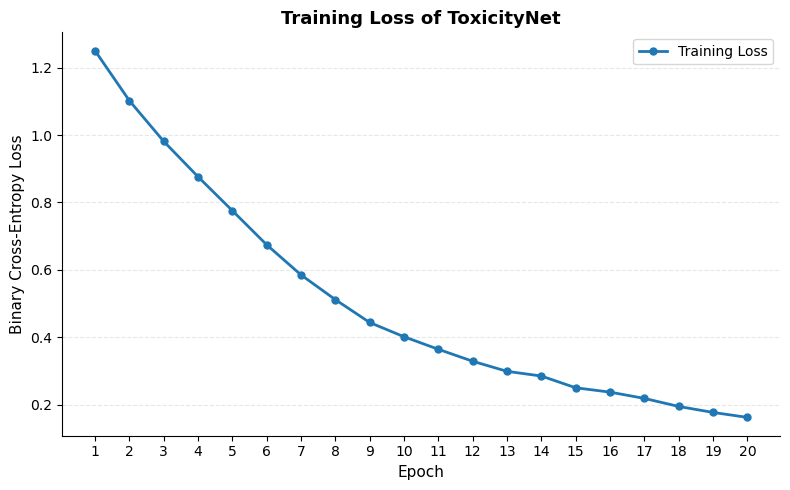

Figure 9 saved successfully ✅


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Load training loss
losses = np.load(os.path.join(BASE, "logs", "training_loss.npy"))

# Epoch numbers
epochs = np.arange(1, len(losses) + 1)

# Create figure
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    losses,
    marker='o',
    linewidth=2,
    markersize=5,
    label="Training Loss"
)

plt.title("Training Loss of ToxicityNet", fontsize=13, fontweight="bold")
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=11)

plt.xticks(epochs)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend()

plt.tight_layout()

# Save publication-quality figure
plt.savefig(
    os.path.join(BASE, "outputs", "plots", "Figure_9_Training_Loss.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Figure 9 saved successfully ✅")

In [9]:
import torch
import numpy as np

# Set model to evaluation mode
model.eval()

# Convert test data
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

# Predict probabilities
with torch.no_grad():
    outputs = model(X_test_t)
    probs = torch.sigmoid(outputs).cpu().numpy()

print("Prediction probabilities shape:", probs.shape)

Prediction probabilities shape: (1565, 12)


In [10]:
threshold = 0.6
preds = (probs > threshold).astype(int)

In [11]:
import pandas as pd
import os

# Save binary predictions
pred_df = pd.DataFrame(preds, columns=tox_cols)

save_path = os.path.join(BASE, "outputs", "predictions", "final_predictions.csv")
pred_df.to_csv(save_path, index=False)

print("Predictions saved successfully ✅")
print("Saved at:", save_path)
print(pred_df.head())

Predictions saved successfully ✅
Saved at: D:\Drug_Toxicity_AI\outputs\predictions\final_predictions.csv
   NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0      0          0       0             0      0          0              0   
1      0          0       0             0      0          0              0   
2      0          0       0             0      0          0              0   
3      0          0       0             0      0          0              0   
4      0          0       0             0      0          0              0   

   SR-ARE  SR-ATAD5  SR-HSE  SR-MMP  SR-p53  
0       0         0       0       0       0  
1       0         0       0       0       0  
2       1         0       0       0       0  
3       0         0       0       0       0  
4       0         0       0       0       0  


In [12]:
import pandas as pd
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics = []

for i, col in enumerate(tox_cols):

    y_true = y_test[:, i]
    y_pred = preds[:, i]

    metrics.append({
        "Label": col,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics)

save_path = os.path.join(
    BASE,
    "outputs",
    "metrics",
    "Table7_ToxicityNet.csv"
)

metrics_df.to_csv(save_path, index=False)

print(metrics_df)
print("\n✅ Table 7 saved successfully!")
print("Saved at:", save_path)

            Label  Accuracy  Precision    Recall        F1
0           NR-AR  0.941214   0.316456  0.396825  0.352113
1       NR-AR-LBD  0.968690   0.489362  0.479167  0.484211
2          NR-AhR  0.895208   0.493750  0.487654  0.490683
3    NR-Aromatase  0.951438   0.285714  0.206897  0.240000
4           NR-ER  0.869649   0.279503  0.338346  0.306122
5       NR-ER-LBD  0.939297   0.278481  0.366667  0.316547
6   NR-PPAR-gamma  0.966773   0.205882  0.218750  0.212121
7          SR-ARE  0.815974   0.285714  0.382514  0.327103
8        SR-ATAD5  0.956550   0.352941  0.339623  0.346154
9          SR-HSE  0.923323   0.237500  0.243590  0.240506
10         SR-MMP  0.868371   0.390863  0.472393  0.427778
11         SR-p53  0.933546   0.378788  0.284091  0.324675

✅ Table 7 saved successfully!
Saved at: D:\Drug_Toxicity_AI\outputs\metrics\Table7_ToxicityNet.csv


In [13]:
import shap
import torch
import numpy as np

# Model setup
model.eval()
model_cpu = model.cpu()

# Use FULL test set
X_sample = X_test
X_sample_t = torch.tensor(X_sample, dtype=torch.float32)

# Background samples for SHAP
background = torch.tensor(X_train[:100], dtype=torch.float32)

# SHAP Explainer
explainer = shap.DeepExplainer(model_cpu, background)

# Compute SHAP values
shap_values = explainer.shap_values(
    X_sample_t,
    check_additivity=False
)

print("SHAP values computed successfully ✅")
print("Number of SHAP outputs:", len(shap_values))

c:\Users\jeffr\miniconda3\envs\drug_ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed successfully ✅
Number of SHAP outputs: 1565


In [14]:
print("Type of SHAP values :", type(shap_values))
print("Number of outputs   :", len(shap_values))
print("Shape of first output:", shap_values[0].shape)

Type of SHAP values : <class 'numpy.ndarray'>
Number of outputs   : 1565
Shape of first output: (512, 12)


In [15]:
import shap
import matplotlib.pyplot as plt
import os

plot_dir = os.path.join(BASE, "outputs", "plots")
os.makedirs(plot_dir, exist_ok=True)

print("Generating SHAP summary plots...")

for i, label in enumerate(tox_cols):

    shap_val = shap_values[:, :, i]

    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_val,
        X_sample,
        show=False,
        max_display=20
    )

    plt.title(f"SHAP Summary Plot - {label}", fontsize=13, fontweight="bold")

    plt.tight_layout()

    plt.savefig(
        os.path.join(plot_dir, f"Figure13_SHAP_{label}.png"),
        dpi=600,
        bbox_inches="tight"
    )

    plt.close()

    print(f"✓ {label}")

print("All SHAP summary plots saved successfully ✅")

Generating SHAP summary plots...


C:\Users\jeffr\AppData\Local\Temp\ipykernel_12980\249023803.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


✓ NR-AR


C:\Users\jeffr\AppData\Local\Temp\ipykernel_12980\249023803.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


✓ NR-AR-LBD


...

✓ SR-HSE


C:\Users\jeffr\AppData\Local\Temp\ipykernel_12980\249023803.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


✓ SR-MMP


C:\Users\jeffr\AppData\Local\Temp\ipykernel_12980\249023803.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


✓ SR-p53
All SHAP summary plots saved successfully ✅


In [16]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
import os
from PIL import Image, ImageDraw
import io

save_dir = os.path.join(BASE, "outputs", "explanations")
os.makedirs(save_dir, exist_ok=True)

# 🎨 Soft label colors
label_colors = {
    "NR-AR": np.array([1, 0.4, 0.4]),
    "NR-AR-LBD": np.array([0.9, 0.5, 0.3]),
    "NR-AhR": np.array([0.4, 0.4, 1]),
    "NR-Aromatase": np.array([1, 1, 0.4]),
    "NR-ER": np.array([0.4, 1, 0.4]),
    "NR-ER-LBD": np.array([0.4, 1, 0.7]),
    "NR-PPAR-gamma": np.array([0.7, 0.7, 0.4]),
    "SR-ARE": np.array([0.4, 1, 1]),
    "SR-ATAD5": np.array([0.7, 0.4, 1]),
    "SR-HSE": np.array([0.4, 0.7, 1]),
    "SR-MMP": np.array([1, 0.6, 0.3]),
    "SR-p53": np.array([1, 0.4, 1])
}

total = len(X_sample)
print(f"Processing {total} molecules...")

for idx in range(total):
    try:
        smiles = df_valid["smiles"].iloc[idx]
        mol = Chem.MolFromSmiles(smiles)

        bit_info = {}
        AllChem.GetMorganFingerprintAsBitVect(mol, 2, 512, bitInfo=bit_info)

        # Store atom contributions
        atom_color = {i: np.array([0.0, 0.0, 0.0]) for i in range(mol.GetNumAtoms())}

        # 🔥 LOOP THROUGH LABELS
        for label_idx, label in enumerate(tox_cols):

            shap_vals = shap_values[idx][:, label_idx]

            # 🔥 USE ALL IMPORTANT BITS (NOT TOP 5)
            threshold_bit = 0.01 * np.max(np.abs(shap_vals))
            important_bits = np.where(np.abs(shap_vals) > threshold_bit)[0]

            base_color = label_colors.get(label, np.array([0.6, 0.6, 0.6]))

            for bit in important_bits:
                if bit in bit_info:
                    for atom_idx, radius in bit_info[bit]:
                        atom_color[atom_idx] += base_color * abs(shap_vals[bit])

        # 🔥 COMPUTE IMPORTANCE
        atom_scores = {k: np.linalg.norm(v) for k, v in atom_color.items()}

        if max(atom_scores.values()) == 0:
            continue

        # 🔥 KEEP MOST ATOMS (CLUSTERS)
        threshold = 0.05 * max(atom_scores.values())
        important_atoms = [k for k, v in atom_scores.items() if v > threshold]

        # 🔥 COLOR PROCESSING
        highlight_colors = {}

        for atom in important_atoms:
            color = atom_color[atom]

            if np.max(color) > 0:
                color = color / np.max(color)

            # Smooth + light colors
            color = 0.6 + 0.3 * color
            color = np.clip(color, 0, 1)

            highlight_colors[atom] = tuple(color)

        highlight_atoms = important_atoms

        # 🔥 DRAW MOLECULE
        drawer = rdMolDraw2D.MolDraw2DCairo(500, 500)

        if len(highlight_atoms) > 0:
            drawer.DrawMolecule(
                mol,
                highlightAtoms=highlight_atoms,
                highlightAtomColors=highlight_colors
            )
        else:
            drawer.DrawMolecule(mol)

        drawer.FinishDrawing()
        img = drawer.GetDrawingText()

        # 🔥 PIL FOR LEGEND
        image = Image.open(io.BytesIO(img))
        draw = ImageDraw.Draw(image)

        # Draw legend
        start_x, start_y = 10, 10
        box_size = 12

        for i, label in enumerate(tox_cols[:5]):
            color = label_colors[label]
            rgb = tuple((np.clip(color, 0, 1) * 255).astype(int))

            y = start_y + i * 18

            draw.rectangle([start_x, y, start_x + box_size, y + box_size], fill=rgb)
            draw.text((start_x + 15, y), label, fill=(0, 0, 0))

        # SAVE
        file_path = os.path.join(save_dir, f"molecule_{idx}.png")
        image.save(file_path)

        if idx % 200 == 0:
            print(f"Saved {idx}/{total}")

    except Exception as e:
        print(f"Error at {idx}: {e}")

print(f"\nGenerated explanations for {total} molecules.")
print(f"Results saved in: {save_dir}")
print("RDKit molecular explanations generated successfully ✅")

Processing 1565 molecules...
Saved 0/1565


[16:22:34] DEPRECATION WARNING: please use MorganGenerator
[16:22:34] DEPRECATION WARNING: please use MorganGenerator
[16:22:34] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerator
[16:22:35] DEPRECATION WARNING: please use MorganGenerat

Saved 200/1565


[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerator
[16:22:38] DEPRECATION WARNING: please use MorganGenerat

Saved 400/1565


...

Saved 1200/1565


[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerator
[16:22:56] DEPRECATION WARNING: please use MorganGenerat

Saved 1400/1565


[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerator
[16:23:00] DEPRECATION WARNING: please use MorganGenerat


Generated explanations for 1565 molecules.
Results saved in: D:\Drug_Toxicity_AI\outputs\explanations
RDKit molecular explanations generated successfully ✅


In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# Pick one molecule
idx = 0

smiles = df_valid["smiles"].iloc[idx]
mol = Chem.MolFromSmiles(smiles)

G = nx.Graph()

# Add atoms (nodes)
for atom in mol.GetAtoms():
    G.add_node(atom.GetIdx(), label=atom.GetSymbol())

# Add bonds (edges)
for bond in mol.GetBonds():
    G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

print("Graph created ✅")

Graph created ✅


In [18]:
# Use same atom_scores from your pipeline
# (reuse your computed atom_scores for this idx)

node_colors = []

for node in G.nodes():
    score = atom_scores.get(node, 0)
    node_colors.append(score)

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

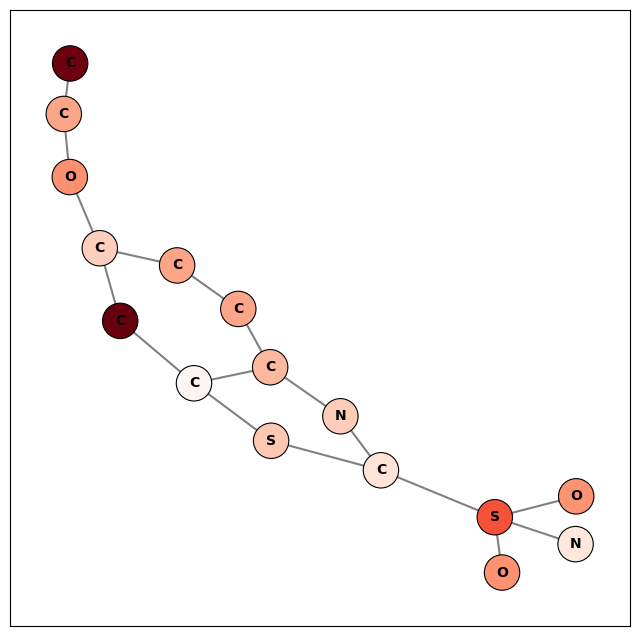

In [19]:
import matplotlib.pyplot as plt
import networkx as nx
import os

plt.figure(figsize=(8, 8))

# Better graph layout
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="gray",
    width=1.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.Reds,
    node_size=650,
    edgecolors="black",
    linewidths=0.8
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=nx.get_node_attributes(G, "label"),
    font_size=10,
    font_weight="bold"
)

plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.Reds),
    label="Atom Importance"
)

plt.title(
    "Molecular Graph with Atom Importance",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(BASE, "outputs", "plots", "Figure16_Molecular_Graph.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Figure 16 saved successfully ✅")

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import os
import numpy as np
import torch
from rdkit import Chem
from rdkit.Chem import AllChem

# -----------------------------
# SETTINGS
# -----------------------------
save_dir = os.path.join(BASE, "outputs", "plots", "clean_test_graphs")
os.makedirs(save_dir, exist_ok=True)

df_data = df_valid   # ✅ use your test/valid dataset

total = len(df_data)
print(f"Processing {total} molecules...")

# -----------------------------
# LOOP
# -----------------------------
for idx in range(total):

    try:
        smiles = df_data["smiles"].iloc[idx]
        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            continue

        # -----------------------------
        # GRAPH CREATION
        # -----------------------------
        G = nx.Graph()

        for atom in mol.GetAtoms():
            G.add_node(atom.GetIdx(), label=atom.GetSymbol())

        for bond in mol.GetBonds():
            G.add_edge(
                bond.GetBeginAtomIdx(),
                bond.GetEndAtomIdx()
            )

        # -----------------------------
        # FINGERPRINT + BIT INFO
        # -----------------------------
        bit_info = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, 2, 512, bitInfo=bit_info
        )

        x = np.array(fp)
        x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0)

        # -----------------------------
        # SHAP (SAFE)
        # -----------------------------
        try:
            shap_vals = explainer.shap_values(
                x_tensor,
                check_additivity=False
            )
            shap_vals = shap_vals[0]

            if isinstance(shap_vals, list):
                shap_vals = np.array(shap_vals)

            if len(shap_vals.shape) == 2:
                shap_combined = np.abs(shap_vals).sum(axis=1)
            else:
                shap_combined = np.abs(shap_vals)

            shap_combined = shap_combined.flatten()

        except:
            shap_combined = np.zeros(512)

        # -----------------------------
        # MAP → ATOM SCORES
        # -----------------------------
        atom_scores = {i: 0.0 for i in range(mol.GetNumAtoms())}

        for bit in range(len(shap_combined)):
            if bit in bit_info:
                for atom_idx, _ in bit_info[bit]:
                    if atom_idx < mol.GetNumAtoms():
                        atom_scores[atom_idx] += float(shap_combined[bit])

        # -----------------------------
        # NORMALIZE SCORES 🔥
        # -----------------------------
        values = np.array(list(atom_scores.values()), dtype=float)

        if len(values) == 0 or np.max(values) == 0:
            norm_scores = np.zeros(len(values))
        else:
            norm_scores = values / np.max(values)

        # -----------------------------
        # COLOR + SIZE 🔥
        # -----------------------------
        node_colors = []
        node_sizes = []

        nodes_list = list(G.nodes())

        for i, node in enumerate(nodes_list):
            score = norm_scores[i]

            if score > 0.6:
                node_colors.append("red")         # high
                node_sizes.append(800)
            elif score > 0.3:
                node_colors.append("orange")      # medium
                node_sizes.append(600)
            else:
                node_colors.append("lightgray")   # low
                node_sizes.append(400)

        # -----------------------------
        # DRAW GRAPH (CLEAN)
        # -----------------------------
        plt.figure(figsize=(6,6))

        pos = nx.kamada_kawai_layout(G)

        nx.draw(
            G,
            pos,
            node_color=node_colors,
            node_size=node_sizes,
            edge_color='gray'
        )

        # -----------------------------
        # LABELS ABOVE NODES 🔥
        # -----------------------------
        labels = nx.get_node_attributes(G, 'label')

        pos_labels = {
            k: (v[0], v[1] + 0.08)
            for k, v in pos.items()
        }

        nx.draw_networkx_labels(
            G,
            pos_labels,
            labels=labels,
            font_size=10,
            font_weight='bold'
        )

        # -----------------------------
        # TITLE + LEGEND
        # -----------------------------
        plt.title(
            f"Molecular Graph {idx}",
            fontsize=13,
            fontweight="bold"
        )

        plt.text(
            0.5, 
            -0.12,
            "Red = High | Orange = Medium | Gray = Low importance",
            ha='center',
            fontsize=9
        )

        # -----------------------------
        # SAVE
        # -----------------------------
        plt.savefig(
            os.path.join(save_dir, f"Figure16_MoleculeGraph_{idx}.png"),
            dpi=600,
            bbox_inches='tight'
        )

        plt.close()

        if idx % 100 == 0:
            print(f"Saved {idx}/{total}")

    except Exception as e:
        print(f"Error at {idx}: {e}")

print(f"\nGenerated {total} molecular graphs.")
print(f"Saved in: {save_dir}")
print("Figure 16 graphs generated successfully ✅")

Processing 7823 molecules...


[16:23:22] DEPRECATION WARNING: please use MorganGenerator


Saved 0/7823


[16:23:23] DEPRECATION WARNING: please use MorganGenerator
[16:23:23] DEPRECATION WARNING: please use MorganGenerator
[16:23:23] DEPRECATION WARNING: please use MorganGenerator
[16:23:24] DEPRECATION WARNING: please use MorganGenerator
[16:23:24] DEPRECATION WARNING: please use MorganGenerator
[16:23:24] DEPRECATION WARNING: please use MorganGenerator
[16:23:25] DEPRECATION WARNING: please use MorganGenerator
[16:23:25] DEPRECATION WARNING: please use MorganGenerator
[16:23:25] DEPRECATION WARNING: please use MorganGenerator
[16:23:26] DEPRECATION WARNING: please use MorganGenerator
[16:23:26] DEPRECATION WARNING: please use MorganGenerator
[16:23:27] DEPRECATION WARNING: please use MorganGenerator
[16:23:27] DEPRECATION WARNING: please use MorganGenerator
[16:23:27] DEPRECATION WARNING: please use MorganGenerator
[16:23:28] DEPRECATION WARNING: please use MorganGenerator
[16:23:28] DEPRECATION WARNING: please use MorganGenerator
[16:23:28] DEPRECATION WARNING: please use MorganGenerat

Error at 95: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. matplotlib.backends._backend_agg.RendererAgg(width: typing.SupportsInt, height: typing.SupportsInt, dpi: typing.SupportsFloat)

Invoked with: 3812, 4492278433, 600


...

<Figure size 600x600 with 1 Axes>

ValueError: Image size of 636x748713072 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 600x600 with 1 Axes>

ValueError: Image size of 623x680648279 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 600x600 with 1 Axes>

In [24]:
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

# 🔥 FUNCTION: Predict + Explain
def predict_and_explain(smiles):

    # -----------------------------
    # 1. SMILES → Molecule
    # -----------------------------
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Invalid SMILES ❌"

    bit_info = {}

    # -----------------------------
    # 2. Fingerprint
    # -----------------------------
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 512, bitInfo=bit_info)
    x = np.array(fp)
    x_tensor = torch.tensor(
        x,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    # -----------------------------
    # 3. MODEL PREDICTION
    # -----------------------------
    model.eval()
    with torch.no_grad():
        output = model(x_tensor).cpu().numpy()[0]

    probabilities = torch.sigmoid(torch.tensor(output)).numpy()
    toxicity_score = float(np.max(probabilities))

    # soften extreme values
    toxicity_score = round(min(toxicity_score, 0.98), 3)

    prediction = "Toxic ⚠️" if toxicity_score > 0.5 else "Non-Toxic ✅"

    # -----------------------------
    # 4. SHAP EXPLANATION
    # -----------------------------
    shap_vals = explainer.shap_values(
    x_tensor.cpu(),
    check_additivity=False
)
    shap_vals = shap_vals[0]

    if len(shap_vals.shape) == 2:
        shap_combined = np.abs(shap_vals).sum(axis=1)
    else:
        shap_combined = np.abs(shap_vals)

    shap_combined = np.array(shap_combined, dtype=float).flatten()

    # -----------------------------
    # 5. IMPORTANT BITS
    # -----------------------------
    if np.max(shap_combined) == 0:
        important_bits = []
    else:
        threshold_bit = 0.01 * np.max(shap_combined)
        important_bits = np.where(shap_combined > threshold_bit)[0]

    # -----------------------------
    # 6. MAP → ATOMS
    # -----------------------------
    atom_scores = {i: 0.0 for i in range(mol.GetNumAtoms())}

    for bit in important_bits:
        if bit in bit_info:
            for atom_idx, radius in bit_info[bit]:
                if atom_idx < mol.GetNumAtoms():
                    atom_scores[atom_idx] += float(shap_combined[bit])

    # -----------------------------
    # 7. FILTER IMPORTANT ATOMS
    # -----------------------------
    values = np.array(list(atom_scores.values()), dtype=float)

    if len(values) == 0 or np.max(values) == 0:
        important_atoms = []
    else:
        max_score = float(np.max(values))
        threshold_atom = 0.1 * max_score

        important_atoms = [
            i for i, v in atom_scores.items()
            if float(v) > threshold_atom
        ]

    # -----------------------------
    # 8. ATOM SYMBOLS
    # -----------------------------
    important_symbols = list(set([
        mol.GetAtomWithIdx(i).GetSymbol()
        for i in important_atoms
    ])) if important_atoms else []

    # -----------------------------
    # 9. FUNCTIONAL GROUP DETECTION
    # -----------------------------
    functional_groups = []

    if mol.HasSubstructMatch(Chem.MolFromSmarts("[OX2H]")):
        functional_groups.append("hydroxyl (OH)")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("[NX3;H2,H1]")):
        functional_groups.append("amine (NH/NH2)")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("[CX3]=O")):
        functional_groups.append("carbonyl (C=O)")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("a1aaaaa1")):
        functional_groups.append("aromatic ring")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("S(=O)(=O)N")):
        functional_groups.append("sulfonamide")

    if mol.HasSubstructMatch(Chem.MolFromSmarts("COC")):
        functional_groups.append("ether")

    # -----------------------------
    # 10. EXPLANATION LOGIC 🔥
    # -----------------------------
    if prediction == "Toxic ⚠️":
        explanation_text = (
            f"The predicted toxicity is primarily influenced by the presence of {', '.join(functional_groups) if functional_groups else 'reactive substructures'}. "
            f"These groups are known to affect molecular reactivity and biological interactions, contributing to toxicity."
        )
    else:
        explanation_text = (
            f"The molecule is predicted to be non-toxic as it lacks strongly reactive or hazardous functional groups. "
            f"The detected groups ({', '.join(functional_groups) if functional_groups else 'none'}) are generally stable "
            f"and less likely to interfere with biological systems."
        )

    # -----------------------------
    # 11. FINAL OUTPUT
    # -----------------------------
    final_explanation = (
        f"SMILES: {smiles}\n\n"
        f"Prediction: {prediction}\n"
        f"Confidence Score: {toxicity_score:.3f}\n\n"
        f"Important atoms: {', '.join(important_symbols) if important_symbols else 'None'}\n"
        f"Functional groups: {', '.join(functional_groups) if functional_groups else 'None'}\n\n"
        f"Explanation:\n{explanation_text}"
    )

    return final_explanation

In [25]:
print("=" * 60)
print("Drug Toxicity Prediction")
print("=" * 60)
result = predict_and_explain("CCOc1ccc2nc(S(N)(=O)=O)sc2c1")
print(result)

Drug Toxicity Prediction
SMILES: CCOc1ccc2nc(S(N)(=O)=O)sc2c1

Prediction: Toxic ⚠️
Confidence Score: 0.980

Important atoms: O, N, C, S
Functional groups: amine (NH/NH2), aromatic ring, sulfonamide

Explanation:
The predicted toxicity is primarily influenced by the presence of amine (NH/NH2), aromatic ring, sulfonamide. These groups are known to affect molecular reactivity and biological interactions, contributing to toxicity.


[17:29:35] DEPRECATION WARNING: please use MorganGenerator


In [26]:
result = predict_and_explain("CCO")
print(result)

SMILES: CCO

Prediction: Non-Toxic ✅
Confidence Score: 0.030

Important atoms: O, C
Functional groups: hydroxyl (OH)

Explanation:
The molecule is predicted to be non-toxic as it lacks strongly reactive or hazardous functional groups. The detected groups (hydroxyl (OH)) are generally stable and less likely to interfere with biological systems.


[17:29:35] DEPRECATION WARNING: please use MorganGenerator
